### Learning Curves and Checking Models’ Scalability

Learning curves show the effect of adding more samples during the training process. The effect is depicted by checking the statistical performance of the model in terms of training score and testing score.

In [1]:
import matplotlib.pyplot as plt

Let's load a somewhat hard classification problem, the digits dataset:

In [2]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

### Performance as a function of dataset size

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Dummy": DummyClassifier(strategy="most_frequent"),
}

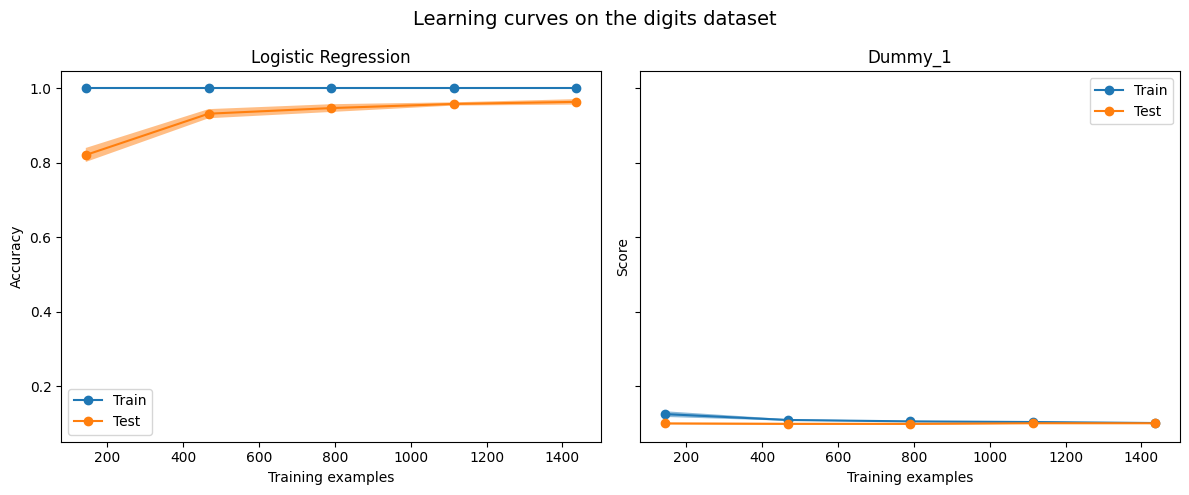

In [ ]:
from sklearn.model_selection import (
    LearningCurveDisplay,
    StratifiedKFold
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, estimator) in zip(axes, models.items()):
    LearningCurveDisplay.from_estimator(
        estimator, X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
        score_type="both",
        std_display_style="fill_between",
        line_kw={"marker": "o"},
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Training examples")

axes[0].set_ylabel("Accuracy")
fig.suptitle("Learning curves on the digits dataset", fontsize=14)
fig.tight_layout()

### Comparing two Models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "GaussianNB": GaussianNB(),
}

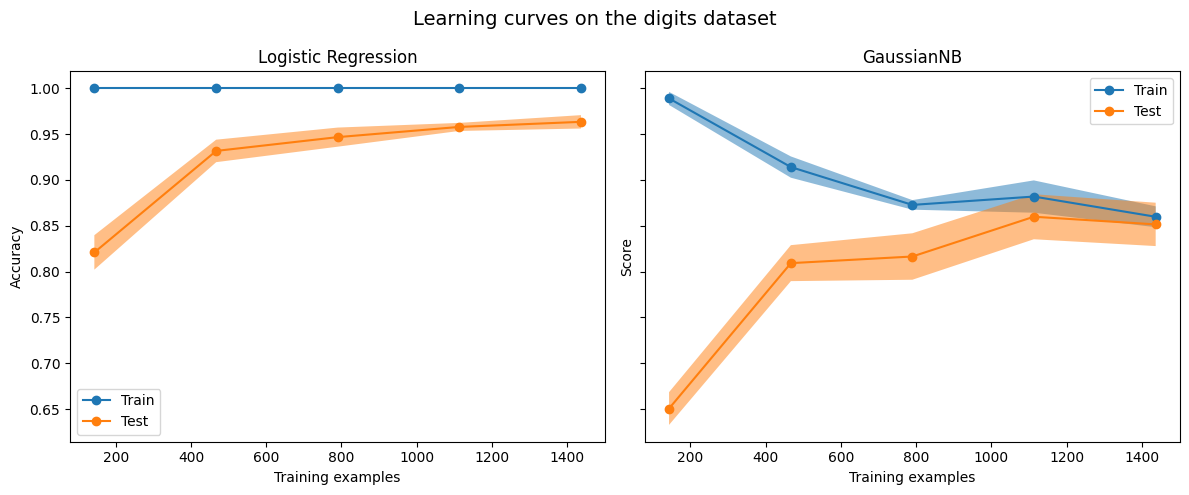

In [ ]:
from sklearn.model_selection import (
    LearningCurveDisplay,
    StratifiedKFold
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, estimator) in zip(axes, models.items()):
    LearningCurveDisplay.from_estimator(
        estimator, X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0),
        score_type="both",
        std_display_style="fill_between",
        line_kw={"marker": "o"},
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Training examples")

axes[0].set_ylabel("Accuracy")
fig.suptitle("Learning curves on the digits dataset", fontsize=14)
fig.tight_layout()

Notice how the `GaussianNB` model performance stops improving beyond `0.85` no matter how much more we increase the dataset size.